# 0 — What a Robot Is

The Five-Layer Robot Stack · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/00-robot-stack/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Before we build anything

The word **robot** is used for at least five different things, and
people arguing about robotics are usually arguing about different
layers.

Today we build the vocabulary for the whole semester:

1.  What the five layers are
2.  What each one is responsible for
3.  How a **real** robot and a **simulated** robot map onto each other
4.  Which layers this course actually lives in

By the end you should be able to hear any robotics claim and ask: *which
layer is this about?*

------------------------------------------------------------------------

## Why a robot has layers at all

Every robot, real or simulated, runs the same loop:

> **sense → decide → act → the world changes → sense again**

The loop is layered for one hard engineering reason: **the parts run at
wildly different speeds.**

A motor must be corrected thousands of times a second. A decision about
*where to walk* need not be revised more than once a second. Bolting
those together in one program produces something that is both too slow
and too twitchy.

The next slides write that loop as three equations, draw it, and then
show why its parts must run at different speeds.

**Layers are a consequence of timescales, not of tidiness.**

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation and every
drawing:

| symbol | meaning | on our G1 | colour |
|------------------|------------------|------------------|------------------|
| ${\color{#3b7dd8}{x}}$ | the **state**: everything needed to predict what happens next | `qpos`, `qvel` | <span style="color:#3b7dd8">blue</span> |
| ${\color{#e8743b}{u}}$ | the **action** (command) sent to the motors | `ctrl` | <span style="color:#e8743b">orange</span> |
| ${\color{#2a9d5c}{y}}$ | the **observation**: what the sensors report | `sensordata` | <span style="color:#2a9d5c">green</span> |
| ${\color{#8e44ad}{\pi}}$ | the **policy**: the rule that turns an observation into an action | your code | <span style="color:#8e44ad">purple</span> |
| ${\color{#c0392b}{\Delta t}}$ | the **timestep**: how much time one tick of the loop covers | `opt.timestep` | <span style="color:#c0392b">red</span> |

A subscript $k$ counts ticks: ${\color{#3b7dd8}{x_k}}$ is the state
after $k$ timesteps, i.e. at time $t = k\,{\color{#c0392b}{\Delta t}}$.

------------------------------------------------------------------------

## The loop as three equations

$${\color{#3b7dd8}{x_{k+1}}} = f({\color{#3b7dd8}{x_k}}, {\color{#e8743b}{u_k}})
\qquad
{\color{#2a9d5c}{y_k}} = h({\color{#3b7dd8}{x_k}})
\qquad
{\color{#e8743b}{u_k}} = {\color{#8e44ad}{\pi}}({\color{#2a9d5c}{y_k}})$$

- $f$ — **the world** (Layer 1): given where everything is and what the
  motors were told, where is everything one timestep later? In
  simulation $f$ is one call, `mujoco.mj_step`; on hardware it is
  reality.
- $h$ — **the sensors** (Layer 2): what the robot can read about its own
  state. It is a function *of* the state, but usually shows only part of
  it — an IMU reports turning and acceleration, never where the robot
  stands.
- ${\color{#8e44ad}{\pi}}$ — **the decision** (Layers 4 and 5): the only
  part you write.

Read them in order and they are one lap of the loop: **sense**
(${\color{#2a9d5c}{y_k}}$ from ${\color{#3b7dd8}{x_k}}$), **decide**
(${\color{#e8743b}{u_k}}$ from ${\color{#2a9d5c}{y_k}}$), **act**
(${\color{#3b7dd8}{x_{k+1}}}$ from both) — then again, for ever. The
whole semester is about ${\color{#8e44ad}{\pi}}$: the first half writes
it by hand, the second half learns it. Sizes on our robot:

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180
import mujoco

model = soc4180.load_g1()
print(f"state x       : qpos {model.nq} + qvel {model.nv} = {model.nq + model.nv} numbers")
print(f"action u      : ctrl {model.nu} numbers (one target angle per motor)")
print(f"observation y : sensordata {model.nsensordata} numbers (2 IMUs x 2 sensors x 3 axes)")

state x       : qpos 36 + qvel 35 = 71 numbers
action u      : ctrl 29 numbers (one target angle per motor)
observation y : sensordata 12 numbers (2 IMUs x 2 sensors x 3 axes)

The robot is described by 71 numbers but *senses* only 12 of them
directly. Closing that gap — estimating ${\color{#3b7dd8}{x}}$ from
${\color{#2a9d5c}{y}}$ — is week 6.

------------------------------------------------------------------------

## The loop, drawn

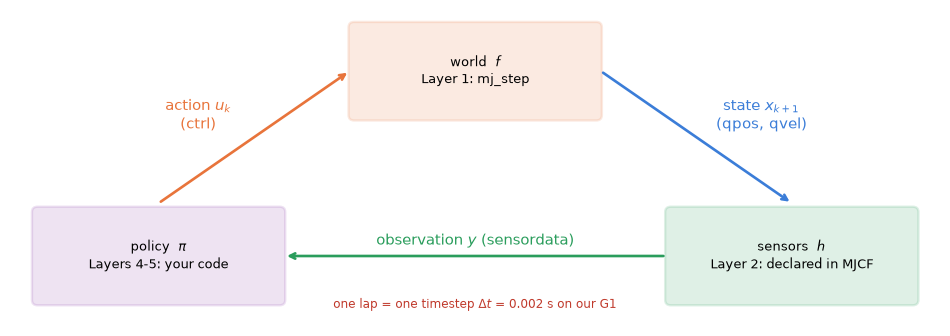

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 3.6)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 3.6)
def box(x, y, txt, col, w=2.6, h=1.0):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06", fc=col, alpha=0.15, ec=col, lw=1.8))
    ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=10)
def arrow(a, b, col, label, off=(0, 0.15), rad=0.0):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="->", lw=2, color=col,
                                                   connectionstyle=f"arc3,rad={rad}"))
    ax.text((a[0] + b[0]) / 2 + off[0], (a[1] + b[1]) / 2 + off[1], label, ha="center", fontsize=11, color=col)
box(3.7, 2.4, "world  $f$\nLayer 1: mj_step", "#e8743b")
box(0.3, 0.3, "policy  $\\pi$\nLayers 4-5: your code", "#8e44ad")
box(7.1, 0.3, "sensors  $h$\nLayer 2: declared in MJCF", "#2a9d5c")
arrow((1.6, 1.4), (3.65, 2.9), "#e8743b", "action $u_k$\n(ctrl)", off=(-0.6, 0.1))
arrow((6.35, 2.9), (8.4, 1.4), "#3b7dd8", "state $x_{k+1}$\n(qpos, qvel)", off=(0.7, 0.1))
arrow((7.05, 0.8), (2.95, 0.8), "#2a9d5c", "observation $y$ (sensordata)", off=(0, 0.12))
ax.text(5.0, 0.2, "one lap = one timestep $\\Delta t$ = 0.002 s on our G1", ha="center", fontsize=9, color="#c0392b")
fig.tight_layout(); plt.show()

Follow the arrows clockwise from the policy: an action goes into the
world, the world moves on by one timestep, the sensors read the new
state, and the policy sees that reading before it chooses the next
action. **No box can skip another**: the policy never touches the state
directly, only what $h$ lets it see, and it never moves the robot
directly, only through $f$.

------------------------------------------------------------------------

## What one timestep is

The real world changes continuously; a computer can only compute a list
of snapshots ${\color{#c0392b}{\Delta t}}$ apart. The rule that jumps
from one snapshot to the next is the **integrator**, and the simplest
one comes straight from the definition of speed.

**Step 1 — speed is change over time:**
$v = \dfrac{\text{change in position}}{\text{time taken}}$, exactly, in
the limit of a tiny time.

**Step 2 — use it for a small but finite time:**
$\text{position}_{k+1} = \text{position}_k + {\color{#c0392b}{\Delta t}} \times \text{velocity}$,
and in the same way
$\text{velocity}_{k+1} = \text{velocity}_k + {\color{#c0392b}{\Delta t}} \times \text{acceleration}$.

**Step 3 — let physics supply the acceleration** (for a dropped ball,
$-g$; for a robot, Newton’s laws for every link) and repeat.

That is all $f$ is: a physics engine computes the accelerations, then
takes one Step 2. It is only an approximation — it pretends nothing
changes *during* ${\color{#c0392b}{\Delta t}}$ — so the smaller the
step, the closer to reality, and the more steps a second of robot time
costs.

------------------------------------------------------------------------

## A timestep, drawn

A ball dropped from the G1’s pelvis height (0.79 m), computed with Step
2 at two timesteps and compared with the exact answer
$z = z_0 - \tfrac12 g t^2$:

dt = 0.050 s: z at t = 0.4 s is -0.0929 m, exact 0.0052 m, error 98.1 mm
dt = 0.002 s: z at t = 0.4 s is 0.0013 m, exact 0.0052 m, error 3.9 mm

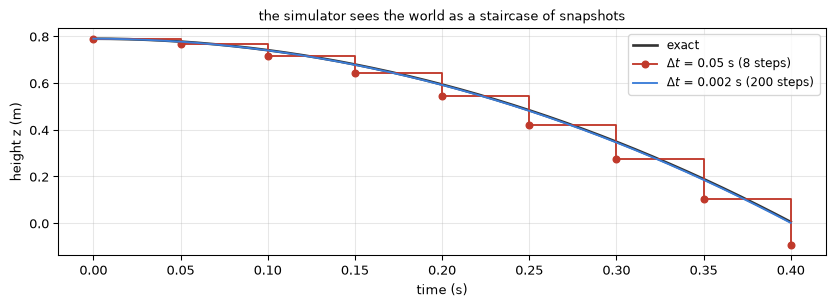

In [3]:
g, z0 = 9.81, 0.79
def drop(dt, t_end=0.4):
    z, v, ts, zs = z0, 0.0, [0.0], [z0]
    for k in range(round(t_end / dt)):
        v = v - dt * g                 # velocity from acceleration
        z = z + dt * v                 # position from velocity (the new one, as MuJoCo does)
        ts.append((k + 1) * dt); zs.append(z)
    return np.array(ts), np.array(zs)

fig, ax = plt.subplots(figsize=(8.8, 3.3))
tt = np.linspace(0, 0.4, 400)
ax.plot(tt, z0 - 0.5 * g * tt**2, color="0.2", lw=2, label="exact")
for dt, col in ((0.05, "#c0392b"), (0.002, "#3b7dd8")):
    ts, zs = drop(dt)
    ax.plot(ts, zs, "o-" if dt > 0.01 else "-", color=col, ms=5, lw=1.4, drawstyle="steps-post" if dt > 0.01 else "default",
            label=f"$\\Delta t$ = {dt} s ({round(0.4 / dt)} steps)")
    print(f"dt = {dt:5.3f} s: z at t = 0.4 s is {zs[-1]:.4f} m, exact {z0 - 0.5 * g * 0.16:.4f} m, "
          f"error {abs(zs[-1] - (z0 - 0.5 * g * 0.16)) * 1000:.1f} mm")
ax.set_xlabel("time (s)"); ax.set_ylabel("height z (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax.set_title("the simulator sees the world as a staircase of snapshots", fontsize=10)
fig.tight_layout(); plt.show()

(A sketch with no floor, so the coarse ball sinks below zero.) Each red
dot is one snapshot; between dots the simulator knows nothing. At
${\color{#c0392b}{\Delta t}}$ = 0.05 s the fall is visibly wrong; at the
G1’s 0.002 s it lies on the exact curve. **Twenty-five times smaller
step, twenty-five times smaller error** — and twenty-five times more
work. Week 1 shows the other price of a step that is too big: not an
error, an explosion.

------------------------------------------------------------------------

## The five layers

| \# | Layer | Nickname | Answers |
|------------------|------------------|------------------|------------------|
| 1 | Physics / World | the body’s reality | What happens when forces act? |
| 2 | Robot Model | the blueprint | What *is* this robot? |
| 3 | Middleware / Robot OS | the nervous system | How do the parts talk? |
| 4 | Control & Planning | the brainstem | What should the motors do *now*? |
| 5 | AI / Behavior | the cortex | What should the robot *achieve*? |

Bottom is fast and dumb. Top is slow and smart.

------------------------------------------------------------------------

## The stack, drawn

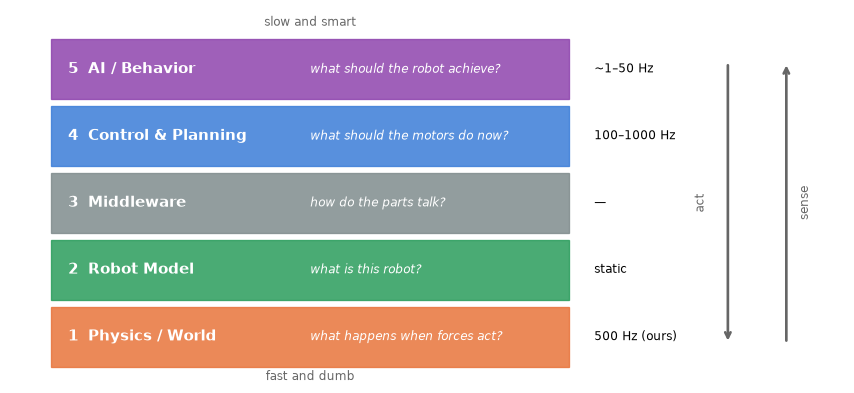

In [4]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import matplotlib.pyplot as plt

layers = [("5  AI / Behavior", "what should the robot achieve?", "~1–50 Hz", "#8e44ad"),
          ("4  Control & Planning", "what should the motors do now?", "100–1000 Hz", "#3b7dd8"),
          ("3  Middleware", "how do the parts talk?", "—", "#7f8c8d"),
          ("2  Robot Model", "what is this robot?", "static", "#2a9d5c"),
          ("1  Physics / World", "what happens when forces act?", "500 Hz (ours)", "#e8743b")]
fig, ax = plt.subplots(figsize=(9, 4.2)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(-0.2, 5.4)
for i, (name, q, rate, col) in enumerate(layers):
    y = 4 - i
    ax.add_patch(plt.Rectangle((0.5, y + 0.05), 6.2, 0.9, color=col, alpha=0.85))
    ax.text(0.7, y + 0.5, name, va="center", fontsize=11, color="w", weight="bold")
    ax.text(3.6, y + 0.5, q, va="center", fontsize=9, color="w", style="italic")
    ax.text(7.0, y + 0.5, rate, va="center", fontsize=9)
ax.annotate("", xy=(9.3, 4.6), xytext=(9.3, 0.4), arrowprops=dict(arrowstyle="->", lw=2, color="0.4"))
ax.text(9.45, 2.5, "sense", rotation=90, va="center", fontsize=9, color="0.4")
ax.annotate("", xy=(8.6, 0.4), xytext=(8.6, 4.6), arrowprops=dict(arrowstyle="->", lw=2, color="0.4"))
ax.text(8.2, 2.5, "act", rotation=90, va="center", fontsize=9, color="0.4")
ax.text(3.6, 5.15, "slow and smart", ha="center", fontsize=9, color="0.4")
ax.text(3.6, -0.15, "fast and dumb", ha="center", fontsize=9, color="0.4")
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

# Layer 1 — Physics / World

------------------------------------------------------------------------

## Layer 1: what it is

The layer that answers *“given these forces, what happens next?”*

**On a real robot there is no physics layer — there is only reality.**
Gravity is not computed. Friction is not a parameter. The world simply
behaves.

**In simulation, a physics engine substitutes for reality.** This is the
one layer that exists only in simulation, and it is the layer
responsible for every way that simulation lies to you.

------------------------------------------------------------------------

## Layer 1: physics engines

| Engine | Typical use |
|------------------------------------|------------------------------------|
| **MuJoCo** | Contact-rich control and RL research — **our engine** |
| PyBullet | Long-standing teaching engine, now largely superseded |
| Isaac Sim / Isaac Lab | GPU-parallel training at industrial scale (NVIDIA) |
| Gazebo | The ROS ecosystem’s default simulator |
| ODE / Bullet / PhysX | Underlying engines used by the above, and by games |

We use MuJoCo because its contact model is good and it is fast enough to
train walking policies. Contact is the whole game in legged robotics:
everything interesting happens where the foot meets the floor.

------------------------------------------------------------------------

## Layer 1: what it computes

- **Integration** — advance the state by one timestep (*What one
  timestep is*, above)
- **Contact detection and response** — who is touching what, with what
  force
- **Friction** — whether the foot slips
- **Inertia and mass distribution** — how the body resists being moved
- **Joint limits** — mechanical stops
- **Actuator dynamics** — how a commanded torque becomes an actual
  torque
- **Sensor simulation** — synthesising IMU, camera, and force readings

Every one of these is an *approximation*, and every one is a place where
a policy that works in simulation can fail on hardware.

------------------------------------------------------------------------

## Layer 1: our engine’s actual settings

In [5]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import mujoco

model = soc4180.load_g1()

print(f"timestep   : {model.opt.timestep} s  ->  {1/model.opt.timestep:.0f} Hz")
print(f"integrator : {mujoco.mjtIntegrator(model.opt.integrator).name}")
print(f"gravity    : {model.opt.gravity}")

timestep   : 0.002 s  ->  500 Hz
integrator : mjINT_IMPLICITFAST
gravity    : [ 0.    0.   -9.81]

500 Hz means one step covers 2 ms of robot time: the loop of the earlier
slides turns 500 times per simulated second. The integrator is
`implicitfast`, a more stable relative of the Step 2 rule (week 1
explains the difference); gravity is $-9.81\ \mathrm{m/s^2}$ along $z$.
The physics runs far faster than any decision-making layer above it.
Remember that number.

------------------------------------------------------------------------

# Layer 2 — Robot Model

------------------------------------------------------------------------

## Layer 2: the blueprint

A file describing **what the robot is**: geometry, mass, joints,
actuators, and sensors.

| Format            | Ecosystem                                |
|-------------------|------------------------------------------|
| **MJCF** (`.xml`) | MuJoCo — **our format**                  |
| **URDF**          | ROS, and the de-facto interchange format |
| **SDF**           | Gazebo                                   |
| USD               | NVIDIA Omniverse / Isaac                 |

A model is a *tree of bodies*. Nesting one body inside another **is**
the kinematic chain — that nesting is what makes the foot move when the
hip turns.

------------------------------------------------------------------------

## Layer 2: a correction worth making early

It is tempting to say “the model is the simulation part.”

**That is wrong.** Real robots need models too:

- Inverse kinematics needs link lengths
- Whole-body control needs the mass matrix
- MPC needs a dynamics model to predict with
- State estimation needs to know where the sensors are

The **model** describes the robot; the **physics engine** simulates the
world. A real G1 carries a model of itself and has no world simulator.
Keep those two apart and Layer 1 versus Layer 2 stops being confusing.

------------------------------------------------------------------------

## Layer 2: what is in our G1

In [6]:
print(f"bodies      nbody = {model.nbody}")
print(f"joints      njnt  = {model.njnt}")
print(f"coordinates nq    = {model.nq}    (position variables)")
print(f"velocities  nv    = {model.nv}    (degrees of freedom)")
print(f"actuators   nu    = {model.nu}    (motors you can command)")
print(f"sensors     nsen  = {model.nsensor}")
print(f"keyframes         = {soc4180.keyframe_names(model)}")

bodies      nbody = 31
joints      njnt  = 30
coordinates nq    = 36    (position variables)
velocities  nv    = 35    (degrees of freedom)
actuators   nu    = 29    (motors you can command)
sensors     nsen  = 4
keyframes         = ['stand']

**`nq` exceeds `nv`.** The floating base stores orientation as a
4-number quaternion but has only 3 rotational freedoms. A robot that can
fall over is not a robot arm bolted to a table, and that one extra
number is where the whole difficulty of legged robotics begins.

------------------------------------------------------------------------

## Layer 2: sensors are declared, not assumed

In [7]:
for i in range(model.nsensor):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    kind = mujoco.mjtSensor(model.sensor_type[i]).name.replace("mjSENS_", "")
    print(f"  {kind:16s} {name}")

  GYRO             imu-torso-angular-velocity
  ACCELEROMETER    imu-torso-linear-acceleration
  GYRO             imu-pelvis-angular-velocity
  ACCELEROMETER    imu-pelvis-linear-acceleration

The G1 declares **two IMUs** — a gyroscope and an accelerometer at both
the torso and the pelvis. That is why `nsensor` is 4 rather than 2:
twelve numbers per step, three axes each.

Note what is **absent**: no camera, no joint-torque sensors, no foot
contact switches. If a controller needs them, you add them to the model.

**A robot cannot sense what its blueprint does not declare.**

------------------------------------------------------------------------

## Layer 2: actuators are not joints

In [8]:
import numpy as np

lo, hi = model.actuator_ctrlrange[0]
print(f"first actuator : {mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, 0)}")
print(f"control range  : [{lo:.3f}, {hi:.3f}] rad")
print(f"position gain  : {model.actuator_gainprm[0][0]:.0f}")
print(f"gains used across all {model.nu} actuators: "
      f"{np.unique(model.actuator_gainprm[:, 0])}")

first actuator : left_hip_pitch_joint
control range  : [-2.531, 2.880] rad
position gain  : 500
gains used across all 29 actuators: [500.]

These are **position servos**: you command an *angle*, and an internal
proportional loop with gain 500 produces the torque:

$$\tau = k_p\,({\color{#e8743b}{\text{ctrl}}} - q) \;-\; k_v\,\dot q, \qquad k_p = 500$$

- ${\color{#e8743b}{\text{ctrl}}}$ — the angle you command (rad): the
  action ${\color{#e8743b}{u}}$
- $q$, $\dot q$ — the joint’s actual angle (rad) and angular speed
  (rad/s), part of the state ${\color{#3b7dd8}{x}}$
- $k_p$ — stiffness, N·m of torque per radian of error; $k_v$ — damping,
  N·m per rad/s
- $\tau$ — the torque the motor applies (N·m)

------------------------------------------------------------------------

## Layer 2: the servo law, in numbers

In [9]:
knee =mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "left_knee_joint")
kv_knee = -model.actuator_biasprm[knee, 2]         # MuJoCo stores the damper as a negative bias
print(f"left knee: kp = {model.actuator_gainprm[knee, 0]:.0f} N·m/rad, kv = {kv_knee:.1f} N·m·s/rad")
print(f"a 0.1 rad error, joint still     -> tau = {500 * 0.1:.0f} N·m pushing it back")
print(f"no error, joint moving at 1 rad/s -> tau = {-kv_knee:.1f} N·m braking it")

left knee: kp = 500 N·m/rad, kv = 15.8 N·m·s/rad
a 0.1 rad error, joint still     -> tau = 50 N·m pushing it back
no error, joint moving at 1 rad/s -> tau = -15.8 N·m braking it

A spring pulling the joint toward its setpoint, plus a damper resisting
motion. Week 5 takes this apart; today it is enough to know that a
*command* is an angle, and a *torque* is what the spring produces when
the joint is not there yet.

**Notice where this law runs**: inside the actuator model, so inside
`mj_step` — inside $f$. On our G1 the fastest part of Layer 4 is
computed by the physics engine at every timestep, which is also how a
real servo drive works: the motor’s own electronics close that loop,
below anything you write.

Hold on to this — it is about to matter more than anything else today.

------------------------------------------------------------------------

# Layer 3 — Middleware / Robot OS

------------------------------------------------------------------------

## Layer 3: the nervous system

The plumbing that lets separately-written programs act as one robot.

| System      | Notes                                                     |
|-------------|-----------------------------------------------------------|
| **ROS 2**   | The dominant standard; DDS-based publish/subscribe        |
| ROS 1       | Legacy, end-of-life, still widely deployed                |
| Vendor SDKs | Unitree, Boston Dynamics, Franka — each proprietary       |
| LCM         | Lightweight messaging from MIT, common in legged robotics |
| YARP        | The iCub humanoid ecosystem                               |
| Drake       | Toolbox with its own systems framework (Toyota Research)  |

A commercial humanoid is typically driven through its **vendor SDK**,
with a **ROS 2 bridge** so the wider ecosystem’s tooling can be used.

------------------------------------------------------------------------

## Layer 3: what it actually provides

- **Transport** — moving messages between processes and across machines
- **Interface contracts** — agreed message types, so parts can be
  swapped
- **Time** — one clock, and the ability to replay logs against it
- **Lifecycle** — starting, stopping, and supervising components
- **Logging** — recording everything, which is how robot bugs actually
  get found
- **Introspection** — observing a running system without stopping it

Middleware buys you **modularity**: perception, control, and planning
become separable programs that different people can write independently.

------------------------------------------------------------------------

## Layer 3: why this course skips it

**We do not use ROS 2, and you should know that is a deliberate
omission.**

- ROS 2 is effectively Linux-only, and cannot run in Colab
- Installing it reliably consumes the opening weeks of a course
- It solves a problem we do not have: we run **one** process, not twelve

What we lose is real: the industry-standard interface, and
career-relevant literacy. If you go into robotics professionally,
**learn ROS 2** — but learn it when the distributed-systems problem it
solves is a problem you actually have.

In our stack, Layer 3 is a single Python process. For one simulated
robot, that is a legitimate architecture rather than a shortcut.

------------------------------------------------------------------------

# Layer 4 — Control & Planning

------------------------------------------------------------------------

## Layer 4: the brainstem

The layer that answers **“what should the motors do, right now?”** —
running hundreds to thousands of times per second, forever.

| Technique | Job |
|------------------------------------|------------------------------------|
| **PID / PD control** | Drive one joint to one setpoint |
| **Inverse kinematics** | Find joint angles that place the foot *there* |
| **Trajectory generation** | A smooth path between poses |
| **ZMP / LIPM walking** | Where to step so that balance is preserved |
| **Whole-body control** | Many objectives at once, subject to physics |
| **MPC** | Optimise over a predicted future, then re-solve every cycle |

Weeks 2–6 of this course are Layer 4, built from scratch.

------------------------------------------------------------------------

## Layer 4: the demonstration that matters

Physics and a blueprint alone do **not** give you a standing robot. Here
is what “no controller” actually means:

In [10]:
with soc4180.actuation_disabled(model):
    data = soc4180.keyframe_data(model, "stand")
    limp_frames = soc4180.render_rollout(
        model, data, duration=3.0, fps=30, width=560, height=420
    )

soc4180.show_video(limp_frames, fps=30)

Actuation disabled: every servo is dead. The robot is a rag doll, and
Layer 1 does what Layer 1 does.

------------------------------------------------------------------------

## Layer 4: now switch the servos on

Same physics, same model, same starting pose. The only change is that a
controller is running.

In [11]:
data = soc4180.keyframe_data(model, "stand")
held_frames = soc4180.render_rollout(
    model, data, duration=3.0, fps=30, width=560, height=420,
    ctrl_fn=soc4180.hold(model, "stand"),
)
soc4180.show_video(held_frames, fps=30)

That is the entire difference between a pile of parts and a robot.

------------------------------------------------------------------------

## Layer 4: measured, not eyeballed

In [12]:
def height_after(seconds, limp):
    d = soc4180.keyframe_data(model, "stand")
    controller = soc4180.hold(model, "stand")

    def run():
        while d.time < seconds:
            if not limp:
                controller(model, d)
            mujoco.mj_step(model, d)

    if limp:
        with soc4180.actuation_disabled(model):
            run()
    else:
        run()
    return d.qpos[2]

print(f"torso height after 3 s, servos OFF : {height_after(3.0, True):.3f} m")
print(f"torso height after 3 s, servos ON  : {height_after(3.0, False):.3f} m")

torso height after 3 s, servos OFF : 0.134 m
torso height after 3 s, servos ON  : 0.792 m

Standing is not a property of the robot. It is a property of the
**loop**.

------------------------------------------------------------------------

## The same numbers, over time

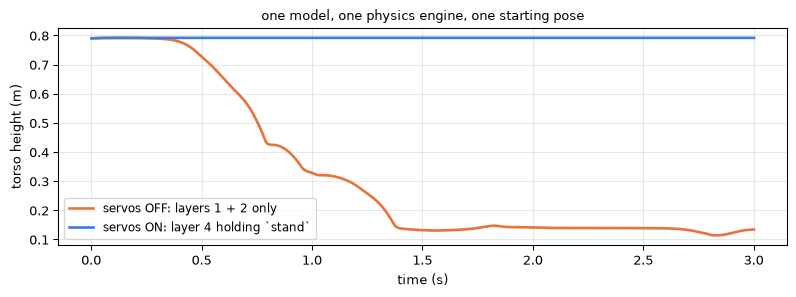

servos OFF: 0.727 m at 0.5 s, below 0.2 m at 1.33 s, lowest 0.114 m at 2.82 s
free fall from 0.79 m to 0.2 m would take 0.35 s

In [13]:
def height_trace(limp, seconds=3.0):
    d = soc4180.keyframe_data(model, "stand")
    controller = soc4180.hold(model, "stand")
    t, z = [], []
    def run():
        while d.time < seconds:
            if not limp:
                controller(model, d)
            mujoco.mj_step(model, d)
            t.append(d.time); z.append(d.qpos[2])
    if limp:
        with soc4180.actuation_disabled(model):
            run()
    else:
        run()
    return np.array(t), np.array(z)

fig, ax = plt.subplots(figsize=(8.4, 3.2))
for limp, col, label in ((True, "#e8743b", "servos OFF: layers 1 + 2 only"),
                         (False, "#3b7dd8", "servos ON: layer 4 holding `stand`")):
    t, z = height_trace(limp)
    ax.plot(t, z, lw=2, color=col, label=label)
ax.set_xlabel("time (s)"); ax.set_ylabel("torso height (m)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title("one model, one physics engine, one starting pose", fontsize=10)
fig.tight_layout(); plt.show()
t, z = height_trace(True)
print(f"servos OFF: {z[np.argmin(abs(t - 0.5))]:.3f} m at 0.5 s, below 0.2 m at {t[np.argmax(z < 0.2)]:.2f} s, "
      f"lowest {z.min():.3f} m at {t[z.argmin()]:.2f} s")
print(f"free fall from 0.79 m to 0.2 m would take {np.sqrt(2 * (0.79 - 0.2) / 9.81):.2f} s")

The blue line is flat to the width of the line. The orange one hardly
moves for half a second — straight legs buckle slowly at first, the way
a pencil standing on its tip starts to tip — then drops through 0.2 m
after about 1.3 s — far slower than a free fall, because the body is not
dropped: it pivots and folds on legs whose feet stay on the floor.
**Nothing about the robot differs between the two lines.**

------------------------------------------------------------------------

## Layer 4: the trap you must not fall into

A robot with `ctrl = 0` is **not** an uncontrolled robot.

Because the G1’s actuators are position servos, `ctrl = 0` commands
*every joint to angle zero* — a straight-legged stance the servos will
happily hold. It looks like “doing nothing”, and is in fact a control
policy.

> **Zero command is a command.**

To see a robot with no controller you must disable actuation, as we just
did. This distinction has ruined many debugging sessions, and it is the
honest answer to *“why does my robot not fall when I do nothing?”*

------------------------------------------------------------------------

# Layer 5 — AI / Behavior

------------------------------------------------------------------------

## Layer 5: the cortex

The layer that answers **“what should the robot achieve?”** — and
increasingly, the layer that *replaces* hand-written parts of Layer 4.

| Technique                     | Job                                       |
|------------------------------------|------------------------------------|
| **Reinforcement learning**    | Learn a locomotion policy from experience |
| **Imitation learning**        | Copy demonstrated motion                  |
| Vision models                 | Turn pixels into state                    |
| Navigation policies           | Choose where to go                        |
| Task planning                 | Decompose a goal into steps               |
| Vision-language-action models | Map instructions to robot actions         |

Weeks 7–15 are Layer 5. This is where the “AI” in the course title
lives.

------------------------------------------------------------------------

## Layer 5: the honest scope of learning

Learned policies have largely won at **locomotion** — walking over
terrain no hand-written controller handled well.

They have **not** replaced the whole stack:

- The physics engine is still hand-written
- The model is still hand-written
- The low-level joint servos are still classical control
- Safety limits are still hard-coded

A modern RL walking policy typically outputs **joint position targets**
at around 50 Hz — which are then tracked by the *same PD servos* from
Layer 4, running ten to twenty times faster.

**The learned policy sits on top of classical control. It does not
delete it.**

------------------------------------------------------------------------

## Timescales: the real reason for layers

| Layer | Typical rate | Why |
|------------------------|------------------------|------------------------|
| 1 Physics | 500 Hz *(ours)* – 1 kHz+ | Stiff contacts and servos need small steps to stay stable (week 1 derives the limit) |
| 4 Joint servo | 500 Hz – 1 kHz | A motor drifts out of position quickly |
| 4 Balance / WBC | 100 – 500 Hz | Falling happens in a few hundred ms |
| 5 Learned policy | ~50 Hz | Enough for gait; more is wasted compute |
| 5 Navigation | 1 – 10 Hz | The world’s layout changes slowly |
| 5 Task planning | \< 1 Hz | Goals change on human timescales |

Roughly three orders of magnitude from bottom to top. **You cannot put a
neural network in a 1 kHz loop, and you do not need to.**

------------------------------------------------------------------------

## The ladder, on a log axis

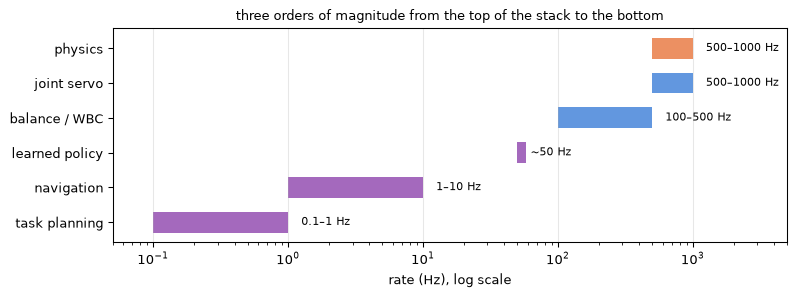

In [14]:
rows = [("task planning", 0.1, 1, "#8e44ad"), ("navigation", 1, 10, "#8e44ad"),
        ("learned policy", 50, 50, "#8e44ad"), ("balance / WBC", 100, 500, "#3b7dd8"),
        ("joint servo", 500, 1000, "#3b7dd8"), ("physics", 500, 1000, "#e8743b")]
fig, ax = plt.subplots(figsize=(8.4, 3.2))
for i, (name, lo, hi, col) in enumerate(rows):
    ax.barh(i, hi - lo if hi > lo else lo * 0.15, left=lo, color=col, alpha=0.8, height=0.6)
    ax.text(hi * 1.25, i, f"{lo:g}–{hi:g} Hz" if hi > lo else f"~{lo:g} Hz", va="center", fontsize=8)
ax.set_yticks(range(len(rows)), [r[0] for r in rows]); ax.set_xscale("log"); ax.set_xlim(0.05, 5000)
ax.set_xlabel("rate (Hz), log scale"); ax.grid(axis="x", alpha=0.3)
ax.set_title("three orders of magnitude from the top of the stack to the bottom", fontsize=10)
fig.tight_layout(); plt.show()

Our policy will run at 50 Hz over 500 Hz physics: **ten physics steps
per decision**, and the servos correct the joints ten times between two
thoughts.

------------------------------------------------------------------------

## Ten steps per decision, drawn

A rate $f$ (Hz, “per second”) and a period $T$ (seconds per tick) are
the same fact: $T = 1/f$. Physics at 500 Hz ticks every
$T_{\text{phys}} = 1/500$ s = 2 ms; a policy at 50 Hz every
$T_{\text{pol}} = 1/50$ s = 20 ms. Physics steps per decision:

$$N = \frac{T_{\text{pol}}}{T_{\text{phys}}} = \frac{f_{\text{phys}}}{f_{\text{pol}}} = \frac{500}{50} = 10 .$$

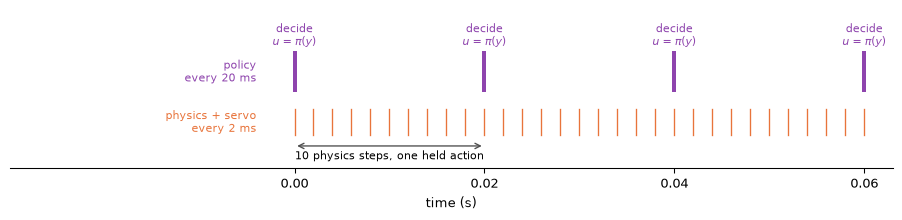

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 2.4))
T = 0.06
for k in range(int(round(T / 0.002)) + 1):
    ax.plot([k * 0.002] * 2, [0, 0.35], color="#e8743b", lw=1)
for k in range(int(round(T / 0.02)) + 1):
    ax.plot([k * 0.02] * 2, [0.6, 1.1], color="#8e44ad", lw=3)
    ax.text(k * 0.02, 1.2, f"decide\n$u$ = $\\pi(y)$", ha="center", fontsize=8, color="#8e44ad")
ax.text(-0.004, 0.17, "physics + servo\nevery 2 ms", ha="right", va="center", fontsize=8, color="#e8743b")
ax.text(-0.004, 0.85, "policy\nevery 20 ms", ha="right", va="center", fontsize=8, color="#8e44ad")
ax.annotate("", xy=(0.02, -0.15), xytext=(0.0, -0.15), arrowprops=dict(arrowstyle="<->", color="0.3"))
ax.text(0.01, -0.33, "10 physics steps, one held action", ha="center", fontsize=8)
ax.set_xlim(-0.03, T + 0.003); ax.set_ylim(-0.45, 1.7); ax.set_yticks([])
ax.set_xticks([0, 0.02, 0.04, 0.06])
ax.set_xlabel("time (s)"); ax.spines[["left", "top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

Between two purple decisions the action is **held**: the same `ctrl` is
sent to ten physics steps, and the servo law on the previous slides
keeps correcting the joints at every orange tick. The slow layer sets
the goal; the fast layer chases it.

------------------------------------------------------------------------

## Real versus simulated, aligned

| Layer | Real Unitree G1 | Our MuJoCo G1 |
|------------------------|------------------------|------------------------|
| **1 Physics** | Reality itself — nothing computes it | **MuJoCo**, 500 Hz, approximate |
| **2 Model** | Onboard kinematic and dynamic model | **MJCF** from Menagerie, pinned |
| **3 Middleware** | Vendor SDK + ROS 2 bridge | One Python process |
| **4 Control** | Onboard joint servos, WBC, MPC | Controllers we write (weeks 2–6) |
| **5 AI** | Policies deployed to the onboard computer | Policies we train (weeks 8–15) |
| **Body** | Motors, encoders, IMU, battery, frame | Numbers in the MJCF |

**Layers 2–5 transfer between the columns. Layer 1 never does.**

That single asymmetry is the entire sim-to-real problem.

------------------------------------------------------------------------

## Where the gap lives

If layers 2–5 are the same code, why does a policy that walks in
simulation fall over on hardware?

Because **Layer 1 was replaced by reality**, and reality disagrees:

- Friction is not a constant, and changes with dust, wear, and
  temperature
- Real motors saturate, heat up, and lag behind their commands
- Real sensors are noisy, biased, and *late*
- Real gearboxes have backlash — a few degrees of nothing before motion
  starts
- Real mass is never exactly the mass written in the file

None of these appear in the MJCF unless somebody puts them there.

**Week 12** attacks this directly: a policy meets physics it did not
train in (other friction, extra mass, weaker servos), and we measure how
far it degrades.

------------------------------------------------------------------------

## Where this course lives

| Weeks | Layer | What you do |
|-------|-------|----------------------------------------------------------|
| **0–1** | all; 1 + 2 | The map; drive the engine and read the blueprint |
| **2–3** | 2 + 4 | Transforms, forward and inverse kinematics |
| **4–5** | 4 | **An analytic walking robot**; actuation, PD control, CPG gaits |
| **6** | 2 + 4 | Sensing and state estimation |
| **7–10** | 4 → 5 | Walking as a learning problem; PPO, reward design, GPU training |
| **11** | 4 | Planning at run time: MPC by sampling |
| **12** | 1 + 5 | Robustness: push recovery, domain randomisation, the sim-to-real gap |
| **13–15** | 5 | Imitation, then pixels, then language |

We spend the first half **building Layer 4 by hand**, so that when Layer
5 replaces it you know exactly what it replaced.

------------------------------------------------------------------------

## What this course does not cover

Stated plainly, so you can fill the gaps deliberately:

- **ROS 2** (Layer 3) — the industry standard; learn it separately
- **Hardware** — no physical robot exists for this course
- **Mechanical design** — motors, gearboxes, and structures are given
- **Electronics and embedded firmware** — below Layer 1 entirely
- **Manipulation** — we walk; we do not grasp

A full humanoid robotics *program* covers all of these. One semester
covers the column from physics to policy, and covers it properly.

------------------------------------------------------------------------

## The question to carry all semester

For any robotics claim, paper, demo, or product announcement:

> **Which layer is this, and what is it assuming about the layers
> beneath it?**

A great deal of robotics hype is a Layer 5 result quietly relying on a
Layer 1 that does not exist outside the laboratory.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/00-robot-stack/lab_stack.py
```

Each key leaves a different set of layers on: `1` physics and model
only, `0` the `ctrl = 0` trap, `2` servos holding `stand`, `3` the week
4 walker, `4` `my_controller` (complete as shipped; change it), `G` Moon
gravity. Contact forces are drawn as arrows — Layer 1, visible. The code
is complete and explained.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `1`, `R`, `2` | torso 0.13 m vs 0.792 m; one sentence on which layer differs |
| 2 | `R`, `0` | a standing robot at 0.791 m, and why zero is a command |
| 3 | `G`, `R`, `1`; then `3` | a slow fall, 54 N of contact force; a walker that does not know it is on the Moon |
| 4 | `4`, change `my_controller` | the arm waves, the robot stands; which layer keeps it up |
| 5 | `ENTER` standing, then walking | 327.1 N on 8 contacts; then 280–340 N on 4–5, and why |
| 6 | ctrl-drag under `2` and `3` | no reaction either way: the missing layer named |

------------------------------------------------------------------------

## Lab class: `stack.py`, the stack you read

``` bash
uv run weeks/00-robot-stack/stack.py --layer hold
uv run weeks/00-robot-stack/stack.py --layer limp --seconds 3
uv run weeks/00-robot-stack/stack.py --layer walk --seconds 9
uv run weeks/00-robot-stack/stack.py --layer wave --gravity 1.62 --no-viewer
```

The same five layers as flags. Simulates headless, printing torso
height, contacts and the contact-force sum against the weight every half
second, then replays the motion in the simulator. Six numbered steps:

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | layers 1+2: robot, gravity, weight | `load_g1`, `keyframe_data`, `opt.gravity`, `body_mass` |
| 2 | layer 4: pick the controller | `key_ctrl`, `WalkingController`, the actuation disable bit |
| 3 | controller writes `ctrl`, one physics step, 500× a second | `mj_step`, `mj_contactForce` |
| 4 | summary: steps/s, distance, warnings | `data.warning` |
| 6 | replay the recorded `qpos` | `launch_viewer(passive=True)`, `mj_forward`, `sync` |

Measured: `hold` 0.792 m and 327.1 N for ever; `limp` 0.134 m; `walk`
1.03 m in 9 s; ~15,000 physics steps/s here, 30× real time.

------------------------------------------------------------------------

## Exercises

1.  **Classify.** Name the layer for each: *a URDF file · PPO · a PID
    gain · a DDS topic · a friction coefficient · a foot trajectory ·
    “fetch me a cup”.*
2.  **Zero is a command.** Run the fall demo with actuation *enabled*
    and `ctrl = 0`. Explain in two sentences why the robot does not
    collapse.
3.  **Break Layer 1.** Set `model.opt.gravity` to the Moon’s
    $-1.62\ \mathrm{m/s^2}$ and re-run the limp fall. Which other layers
    had to change? (None — that is the point.)
4.  **Sensor absence.** The G1 model declares no foot contact sensors.
    Name one Layer 4 technique from these slides that becomes harder
    without them.
5.  **Timescale.** A policy runs at 50 Hz while physics runs at 500 Hz.
    How many physics steps pass between two policy decisions, and what
    must the servos do in between?

------------------------------------------------------------------------

## Next: 01

We stop talking about the stack and start driving it — loading the
model, stepping the engine, and rendering what comes out.

Bring today’s vocabulary. Every week from here names its layer.